# Weight Initialization Techniques
- Weight Initialization Methods SHOULD NOT USE
1. Zero Initialization
2. Constant Initialization (all weights = k)
3. Very Large Random Values
4. Very Small Random Values
5. Random Initialization Without Scaling (Old method)

## Table Of Content
```markdown
1. Zero Initialization
  - Weight Update
  - Check Model Weights
2. Constant Initialization
  - Weight Update
  - Check Model Weights
3. Small Value Initialization
  - Weight Update
  - Check Model Weights
4. Larger Value Initialization
  - Weight Update
  - Check Model Weights
```

# Import Libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [60]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.activations import relu, tanh, sigmoid
from keras.losses import BinaryCrossentropy

from keras import regularizers

In [93]:
import random

# Make Dataset

In [61]:
X, y = make_moons(n_samples=100, noise=0.1, random_state=0)

# Plot Dataset

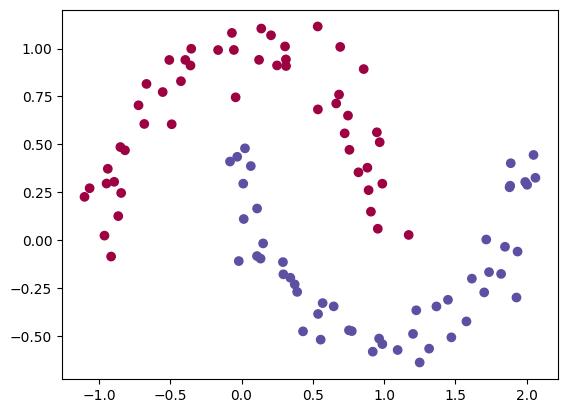

In [62]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)

# Train Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Zero Initialize

In [64]:
model1 = Sequential()
model1.add(Input(shape=(2,)))
# model1.add(Dense(1, activation='sigmoid', kernel_initializer='zeros', bias_initializer='zeros'))
model1.add(Dense(2, activation=sigmoid))
model1.add(Dense(2, activation=tanh))
model1.add(Dense(1, activation=sigmoid))

In [65]:
model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## Weight Update

In [66]:
# weights = model1.get_weights()
# weights[0] = np.zeros_like(weights[0])
# weights[1] = np.zeros_like(weights[1])
# weights[2] = np.zeros_like(weights[2])

# model1.set_weights(weights)

In [67]:
model1.get_weights()

[array([[ 0.6412575 , -1.1571094 ],
        [-0.01549327,  1.1214184 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.0277023 ,  1.1084572 ],
        [-0.09740281,  0.93953025]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.55689204],
        [-0.990309  ]], dtype=float32),
 array([0.], dtype=float32)]

In [68]:
weights = model1.get_weights()
weights = [np.zeros_like(w) for w in weights]
model1.set_weights(weights)

In [69]:
model1.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [70]:
model1.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [71]:
model1.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

## Check Model Weights

In [72]:
model1.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.02904256], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

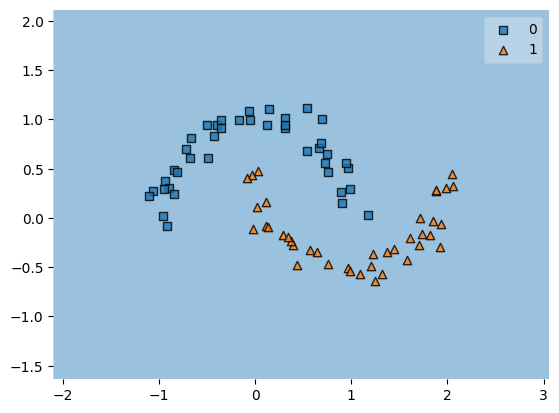

In [73]:
plot_decision_regions(X_train, y_train, clf=model1)

# Constant Initialization

In [76]:
model2 = Sequential()
model2.add(Input(shape=(2,)))

model2.add(Dense(2, activation=sigmoid))
model2.add(Dense(2, activation=tanh))

model2.add(Dense(1, activation=sigmoid))

In [77]:
model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## weight update

In [78]:
model2.get_weights()

[array([[-0.5584347, -0.6875454],
        [-0.9705943, -0.5372398]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.46389616, -0.42382067],
        [-0.95221627, -0.70381576]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.23857033],
        [-0.13121498]], dtype=float32),
 array([0.], dtype=float32)]

In [82]:
weights = model2.get_weights()
weights = [np.full_like(w, 0.5) for w in weights]
model2.set_weights(weights)

In [83]:
model2.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [84]:
model2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [85]:
model2.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

## Check Model Weights

In [86]:
model2.get_weights()

[array([[ 0.7230301,  0.7230301],
        [-2.7937717, -2.7937717]], dtype=float32),
 array([-0.48697922, -0.48697922], dtype=float32),
 array([[1.5616152, 1.5616152],
        [1.5616152, 1.5616152]], dtype=float32),
 array([-0.9913582, -0.9913582], dtype=float32),
 array([[1.59325],
        [1.59325]], dtype=float32),
 array([-0.1923073], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

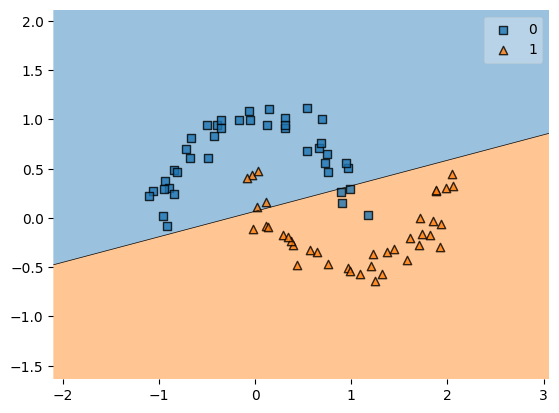

In [87]:
plot_decision_regions(X_train, y_train, clf=model2)

# Very Small Values

In [136]:
model3 = Sequential()
model3.add(Input(shape=(2,)))

model3.add(Dense(2, activation=tanh))
model3.add(Dense(2, activation=tanh))

model3.add(Dense(1, activation=sigmoid))

In [137]:
model3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## Weight Update

In [138]:
model3.get_weights()

[array([[-0.5992925 ,  0.749503  ],
        [-1.0320987 ,  0.07159626]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.17519677, -0.47865164],
        [ 0.86285293, -0.46658117]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.99939823],
        [-1.26156   ]], dtype=float32),
 array([0.], dtype=float32)]

In [139]:
weights = model3.get_weights()

new_weights = []
counter = 0

for w in weights:
    size = w.size                              # number of elements
    vals = np.arange(counter, counter + size)   # unique values
    vals = vals.reshape(w.shape) * 0.00001        # reshape + scale
    counter += size
    new_weights.append(vals)

model3.set_weights(new_weights)
model3.get_weights()

[array([[0.e+00, 1.e-05],
        [2.e-05, 3.e-05]], dtype=float32),
 array([4.e-05, 5.e-05], dtype=float32),
 array([[6.e-05, 7.e-05],
        [8.e-05, 9.e-05]], dtype=float32),
 array([0.0001 , 0.00011], dtype=float32),
 array([[0.00012],
        [0.00013]], dtype=float32),
 array([0.00014], dtype=float32)]

In [140]:
model3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [141]:
model3.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

## Check Model Weights

In [142]:
new_weights

[array([[0.e+00, 1.e-05],
        [2.e-05, 3.e-05]]),
 array([4.e-05, 5.e-05]),
 array([[6.e-05, 7.e-05],
        [8.e-05, 9.e-05]]),
 array([0.0001 , 0.00011]),
 array([[0.00012],
        [0.00013]]),
 array([0.00014])]

In [143]:
model3.get_weights()

[array([[-0.26440045, -0.26458573],
        [ 1.2158111 ,  1.2160931 ]], dtype=float32),
 array([0.00011826, 0.00062994], dtype=float32),
 array([[-1.1153681, -1.1144964],
        [-1.1185654, -1.1177402]], dtype=float32),
 array([0.14143904, 0.14217286], dtype=float32),
 array([[1.7042334],
        [1.7052739]], dtype=float32),
 array([0.22967581], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

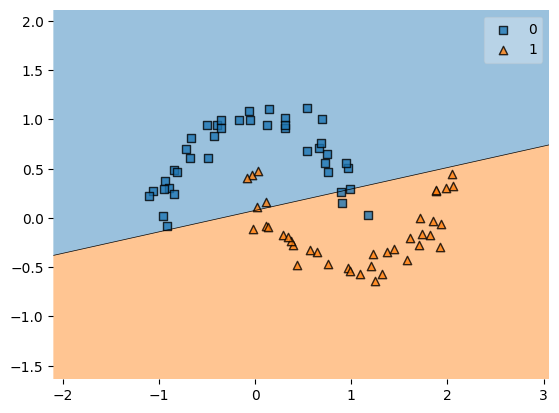

In [144]:
plot_decision_regions(X_train, y_train, clf=model3)

# Big Weight Initialization

In [145]:
model4 = Sequential()
model4.add(Input(shape=(2,)))

model4.add(Dense(2, activation=sigmoid))
model4.add(Dense(2, activation=tanh))

model4.add(Dense(1, activation=sigmoid))

In [146]:
model4.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## Weight Update

In [147]:
model4.get_weights()

[array([[ 1.0768789,  0.5215826],
        [ 0.5777583, -0.5352399]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.01190519, -0.5981511 ],
        [ 0.44143188, -0.5705569 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.6232985],
        [0.8150567]], dtype=float32),
 array([0.], dtype=float32)]

In [152]:
weights4 = model4.get_weights()

new_weights4 = []

for w in weights4:
    size = w.size
    vals = np.random.rand(size).reshape(w.shape)*2
    new_weights4.append(vals)

model4.set_weights(new_weights4)
model4.get_weights()

[array([[0.2569808, 1.6646153],
        [1.3155868, 0.9318694]], dtype=float32),
 array([0.4976364, 0.6399808], dtype=float32),
 array([[1.9802215 , 1.8569516 ],
        [1.3172021 , 0.16502029]], dtype=float32),
 array([0.8120168 , 0.57640237], dtype=float32),
 array([[1.9967843 ],
        [0.13299924]], dtype=float32),
 array([1.9707588], dtype=float32)]

In [153]:
model4.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [154]:
model4.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

## Check Model Weights

In [155]:
new_weights4

[array([[0.25698082, 1.66461526],
        [1.31558676, 0.93186942]]),
 array([0.4976364, 0.6399808]),
 array([[1.98022148, 1.85695163],
        [1.31720206, 0.16502028]]),
 array([0.81201676, 0.57640234]),
 array([[1.99678434],
        [0.13299924]]),
 array([1.97075882])]

In [156]:
model4.get_weights()

[array([[ 1.1585923,  1.1161257],
        [-1.8369294, -2.4663682]], dtype=float32),
 array([-0.85196453, -0.6460709 ], dtype=float32),
 array([[1.6497123 , 2.7244802 ],
        [1.1283453 , 0.96358085]], dtype=float32),
 array([-1.0223824,  2.2914093], dtype=float32),
 array([[ 1.9300011],
        [-0.9262739]], dtype=float32),
 array([0.9060073], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

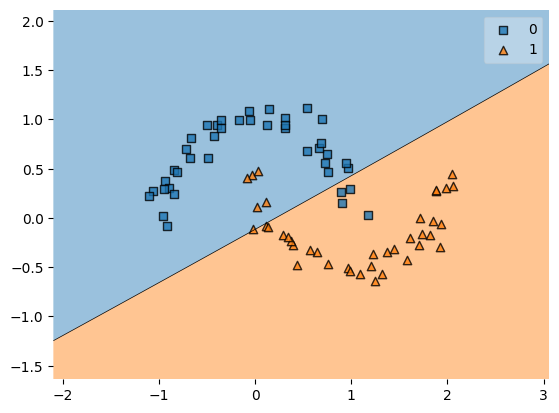

In [157]:
plot_decision_regions(X_train, y_train, clf=model4)